In [1]:
import sys
import os
import torch
from torch.autograd import Function
torch.set_default_dtype(torch.float64)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import scipy
from scipy.sparse import csr_matrix
sys.path.insert(1, os.path.join(sys.path[0], os.pardir, os.pardir))
import time
import argparse
import pyomo.environ as pyo
import numpy as np
import torch
import time
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io as spio
current_dir = os.getcwd()
dir = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))
sys.path.append(dir) # Add the parent directory to Python's search path
from Opt_Layer.pyomolayer import PyomoOptLayer

Process 0/1: MPI initialized


[kchen2-39554s:40804] shmem: mmap: an error occurred while determining whether or not /var/folders/9q/8xflrcr1627by_srmypl9dv96x3ntg/T//ompi.kchen2-39554s.1305597775/jf.0/4130275328/sm_segment.kchen2-39554s.1305597775.f62f0000.0 could be created.


In [2]:
def str_to_bool(value):
    if isinstance(value, bool):
        return value
    if value.lower() in {'false', 'f', '0', 'no', 'n'}:
        return False
    elif value.lower() in {'true', 't', '1', 'yes', 'y'}:
        return True
    raise ValueError('{value} is not a valid boolean value')

def my_hash(string):
    return hashlib.sha1(bytes(string, 'utf-8')).hexdigest()

In [3]:
parser = argparse.ArgumentParser(description='DC3')
parser.add_argument('--probType', type=str, default='acopf57', help='problem type')
parser.add_argument('--epochs', type=int, default=1000,
    help='number of neural network epochs')
parser.add_argument('--batchSize', type=int, default=32,
    help='training batch size')
parser.add_argument('--lr', type=float, default=0.0005,
    help='neural network learning rate')
parser.add_argument('--hiddenSize', type=int, default=10,
    help='hidden layer size for neural network')
parser.add_argument('--saveAllStats', type=str_to_bool, default=False,
    help='whether to save all stats, or just those from latest epoch')
parser.add_argument('--resultsSaveFreq', type=int, default=10,
    help='how frequently (in terms of number of epochs) to save stats to file')

args = parser.parse_args([])
args = vars(args) # change to dictionary
print(args)

{'probType': 'acopf57', 'epochs': 1000, 'batchSize': 32, 'lr': 0.0005, 'hiddenSize': 10, 'saveAllStats': False, 'resultsSaveFreq': 10}


In [4]:
def create_model(nominal_p):
    # Create a concrete model
    m = pyo.ConcreteModel()

    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    # Define variables
    m.x = pyo.Var(range(1), within=pyo.Reals)
    m.s = pyo.Var(range(1), within=pyo.Reals)
    m.p = pyo.Var(range(1), within=pyo.Reals)
    
    m.obj_weight = pyo.Param(initialize=0, within=pyo.NonNegativeReals, mutable=True)
    m.p[0].fix(nominal_p[0])
    m.s[0].fix(0)
    # Define equality constraints
    m.equ_constraints = pyo.ConstraintList()

    m.equ_constraints.add(m.x[0] - m.p[0] + m.s[0] == 0)
    
    m.inequ_constraints = pyo.ConstraintList()
    m.inequ_constraints.add(m.x[0] >= 0)
    
    # Define objective function: 
    def objective_rule(m):
        return m.obj_weight * m.x[0] + m.s[0]**2 
        
    m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
    return m

In [6]:
def create_model(nominal_p):
    # Create a concrete model
    m = pyo.ConcreteModel()

    m.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zL_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)
    m.ipopt_zU_out = pyo.Suffix(direction=pyo.Suffix.IMPORT)

    # Define variables
    m.x = pyo.Var(within=pyo.NonNegativeReals)
    m.p = pyo.Var(within=pyo.Reals)
    m.s_pos = pyo.Var(range(1), within=pyo.NonNegativeReals, initialize=0)
    m.s_neg = pyo.Var(range(1), within=pyo.NonNegativeReals, initialize=0)

    m.obj_weight = pyo.Param(initialize=0, within=pyo.NonNegativeReals, mutable=True)
    m.p.fix(nominal_p[0])
    m.s_pos[0].fix(0)
    m.s_neg[0].fix(0)
    # Define equality constraints
    m.equ_constraints = pyo.ConstraintList()

    m.equ_constraints.add(m.x - m.p + m.s_pos[0] - m.s_neg[0] == 0)
    
    # Define objective function: 
    def objective_rule(m):
        return m.obj_weight * m.x**2 + m.s_pos[0] + m.s_neg[0] 
        
    m.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)
     
    return m

In [7]:
np.random.seed(0)
p = np.abs(np.random.rand(1))
print(p)
model = create_model(p)
opt = pyo.SolverFactory('ipopt')
results = opt.solve(model, tee=True) 
print(results)
model.display()
print(model.obj())

[0.5488135]
Ipopt 3.14.17: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:        1
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:        1
                     variables with only lower bounds:        1
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1


In [8]:
class NNSolver(nn.Module):
    def __init__(self, in_features, out_features, args):
        super().__init__()
        self._args = args
        torch.manual_seed(0)
        self.layers1 = nn.Linear(in_features, self._args['hiddenSize'])
        self.relu = nn.ReLU(inplace=True)
        torch.manual_seed(0)
        self.layers2 = nn.Linear(self._args['hiddenSize'], out_features)
        torch.manual_seed(0)
        self.layers3 = nn.Linear(self._args['hiddenSize'], self._args['hiddenSize'])
        
    def forward(self, x):

        out = self.layers1(x)
        
        out = self.relu(out)

        out = self.layers2(out)

        return out

In [9]:
torch.manual_seed(1)  # fix seed if needed

total_sample = 10
in_features = 1
out_features  = 1

dataset = torch.rand(total_sample, in_features) * 2 - 1

trainX_new = dataset[:int(total_sample * 0.8), :]
validX_new = dataset[int(total_sample * 0.8):int(total_sample * 0.9), :]
testX_new = dataset[int(total_sample * 0.9):, :]

print(trainX_new.shape)
print(validX_new.shape)
print(testX_new.shape)

y_dataset = dataset**2
trainY_new = y_dataset[:int(total_sample * 0.8), :]
validY_new = y_dataset[int(total_sample * 0.8):int(total_sample * 0.9), :]
testY_new = y_dataset[int(total_sample * 0.9):, :]
print(trainY_new.shape)

solver_step = args['lr']
nepochs = args['epochs']
batch_size = args['batchSize']

train_dataset = TensorDataset(trainX_new, trainY_new)
valid_dataset = TensorDataset(validX_new, validY_new)
test_dataset = TensorDataset(testX_new, testY_new)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=len(valid_dataset))
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset))

torch.Size([8, 1])
torch.Size([1, 1])
torch.Size([1, 1])
torch.Size([8, 1])


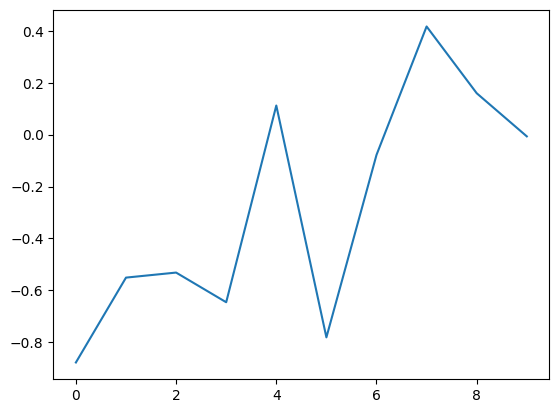

In [10]:
plt.plot(dataset)

In [11]:
super_weight = 0.01
obj_weight = 0.1

solver_net = NNSolver(in_features, out_features, args)
solver_opt = optim.Adam(solver_net.parameters(), lr=solver_step)

stats = {}
batch_loss = []
epoch_loss = []

batch_loss_super = []
epoch_loss_super = []

batch_loss_unsuper = []
epoch_loss_unsuper = []

In [12]:
variables_name = [model.x]
parameters_name = [model.p]
slacks_name = [model.s_pos, model.s_neg]
known_parameters_name = None
free_parameters_name = None
Layer = PyomoOptLayer(model, variables_name, parameters_name, free_parameters_name, known_parameters_name, slacks_name)

In [14]:
Xtrain

tensor([[-0.0782],
        [ 0.4167],
        [-0.7811],
        [-0.8779],
        [ 0.1121],
        [-0.5509],
        [-0.6458],
        [-0.5315]])

In [13]:
start_time = time.time()
for i in range(50):
    epoch_stats = {}
    
    # Get train loss
    solver_net.train()
    Layer.train()
    for Xtrain, Ytrain in train_loader:

        solver_opt.zero_grad()

        Yhat_train = solver_net(Xtrain) 

        input = tuple([Yhat_train])

        primal_batch, slack_out, dual_out,  _, _, _ = Layer(*input)

        primal_loss = torch.mean((primal_batch - Ytrain)**2, dim = 0) + (slack_out**2).mean()

        if slack_out is not None:
            unsupervised_loss = (slack_out**2).mean()
            train_loss = primal_loss 
        else:
            train_loss = primal_loss
            unsupervised_loss = 0.0

        train_loss.backward()
        solver_opt.step()

        batch_loss.append(train_loss.detach().cpu().numpy())
        batch_loss_super.append(primal_loss.detach().cpu().numpy())
        try:
            batch_loss_unsuper.append(unsupervised_loss.detach().cpu().numpy())
        except:
            batch_loss_unsuper.append(0.0)
        
    # solver_net.eval()
    # Layer.eval()
    # start_time_eval = time.time()
    # with torch.no_grad():
    #     for Xvalid, in valid_loader:

    #         Yhat_valid = solver_net(Xvalid).detach()

    #         input = tuple([Yhat_valid])

    #         primal_batch, slack_out, _, _, _ = Layer(*input)

    print('Epoch {}: train loss {:.6f}, train unsup loss {:.6f}, primal loss {:.6f}'.format(
            i, np.mean(batch_loss), np.mean(batch_loss_unsuper), np.mean(batch_loss_super)))
    
    epoch_loss.append(np.mean(batch_loss))
    epoch_loss_unsuper.append(np.mean(batch_loss_unsuper))
    epoch_loss_super.append(np.mean(batch_loss_super))

    batch_loss = []
    batch_loss_unsuper = []
    batch_loss_super = []

train_time = time.time() - start_time
print(train_time)

params [tensor([-0.0468], requires_grad=True)]
params_ [array([-0.04684963])]
params_flat [-0.04684963]
Model unknown

  Variables:
    x : Size=1, Index=None
        Key  : Lower : Value              : Upper : Fixed : Stale : Domain
        None :     0 : 0.5488135039273248 :  None : False : False : NonNegativeReals
    p : Size=1, Index=None
        Key  : Lower : Value                 : Upper : Fixed : Stale : Domain
        None :  None : -0.046849629491103925 :  None :  True : False :  Reals
    s_pos : Size=1, Index={0}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :   0.0 :  None :  True : False : NonNegativeReals
    s_neg : Size=1, Index={0}
        Key : Lower : Value : Upper : Fixed : Stale : Domain
          0 :     0 :   0.0 :  None :  True : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True :   0.0

  Constraints:
    equ_constraints : Size=1
        Key 

TypeError: PyomoLayerFn.<locals>.PyomoLayerFnFn.backward() takes from 3 to 6 positional arguments but 7 were given

In [24]:
for Xvalid, Yvalid in valid_loader:
    Yhat_valid = solver_net(Xvalid).detach()
    input = tuple([Yhat_valid])
    primal_batch, slack_out, dual_out, _, _ = Layer(*input)
print(torch.mean(primal_batch - Yvalid)**2)

{Member of equ_constraints} : Size=1, Index={1}, Active=True
    Key : Lower : Body               : Upper : Active
      1 :   0.0 : x[0] - p[0] - s[0] :   0.0 :   True
concrete_model.dual[constraint] 0.0
{Member of inequ_constraints} : Size=2, Index={1, 2}, Active=True
    Key : Lower : Body : Upper : Active
      1 :   0.0 : x[0] :  +Inf :   True
concrete_model.dual[constraint] 0.0
{Member of inequ_constraints} : Size=2, Index={1, 2}, Active=True
    Key : Lower : Body : Upper : Active
      2 :   0.0 : s[0] :  +Inf :   True
concrete_model.dual[constraint] 0.0
tensor([[[1.]]])
tensor(0.0001)


In [25]:
dual_out

tensor([[0., 0., 0.]])

In [97]:
dual_out

tensor([[ 1.3939e-01, -1.3939e-01, -6.9457e-08],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [ 1.3243e-02, -1.3243e-02, -4.0549e-07],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [ 1.8828e-01, -1.8828e-01, -6.0300e-08],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [ 1.9758e-01, -1.9758e-01, -4.8723e-08],
        [ 3.3475e-01, -3.3475e-01, -1.5660e-08],
        [ 9.8403e-02, -9.8403e-02, -9.7490e-08],
        [ 4.7940e-01, -4.7940e-01, -1.0588e-08],
        [ 1.5998e-02, -1.5998e-02, -3.2102e-07],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [ 2.3815e-01, -2.3815e-01, -2.6906e-08],
        [ 3.8147e-01, -3.8147e-01, -1.3406e-08],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [ 3.4559e-01, -3.4559e-01, -1.5086e-08],
        [ 4.5469e-01

In [98]:
print(primal_batch)
print(slack_out)

tensor([[-7.5474e-09, -8.7618e-09,  6.6278e-02],
        [ 1.0097e-01, -7.4589e-09, -7.5218e-09],
        [ 3.4936e-01, -7.4840e-09, -7.5035e-09],
        [-8.6764e-09, -9.0417e-09,  2.8697e-03],
        [ 1.4192e-01, -7.4686e-09, -7.5161e-09],
        [ 6.2386e-01, -7.4889e-09, -7.4983e-09],
        [-7.5329e-09, -8.7575e-09,  9.0854e-02],
        [ 4.8129e-01, -7.4887e-09, -7.4978e-09],
        [ 1.6633e-01, -7.4725e-09, -7.5129e-09],
        [-7.5334e-09, -8.7558e-09,  9.5530e-02],
        [-7.5153e-09, -8.7526e-09,  1.6452e-01],
        [-7.5848e-09, -8.7649e-09,  4.5677e-02],
        [-7.5088e-09, -8.7508e-09,  2.3688e-01],
        [-8.2919e-09, -8.9460e-09,  4.2544e-03],
        [ 5.2415e-01, -7.4886e-09, -7.4981e-09],
        [ 4.4387e-01, -7.4863e-09, -7.5016e-09],
        [-7.5267e-09, -8.7542e-09,  1.1619e-01],
        [-7.5126e-09, -8.7518e-09,  1.8789e-01],
        [ 5.6735e-01, -7.4887e-09, -7.4983e-09],
        [-7.5152e-09, -8.7520e-09,  1.6994e-01],
        [-7.5095e-09

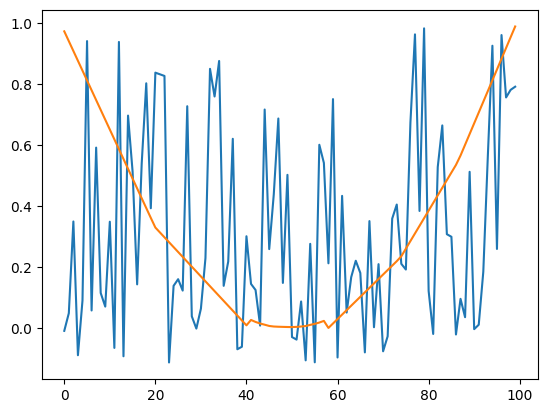

In [461]:
plt.plot(Yhat_valid)
plt.plot(primal_batch)

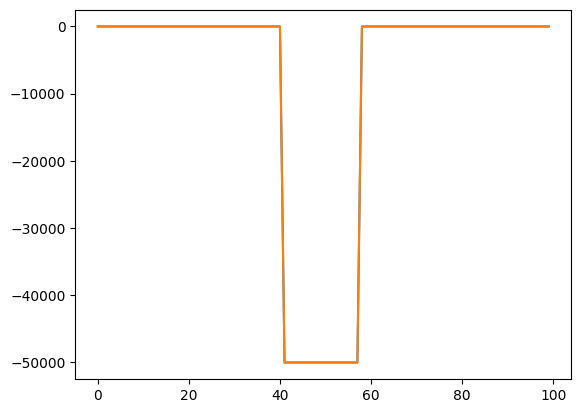

In [457]:
plt.plot(slack_out)

In [454]:
x = torch.linspace(-1, 1, 100).unsqueeze(1)
y = solver_net(x).detach()
y_target = x**2
input = tuple([y])
primal_batch, slack_out, _, _, _ = Layer(*input)

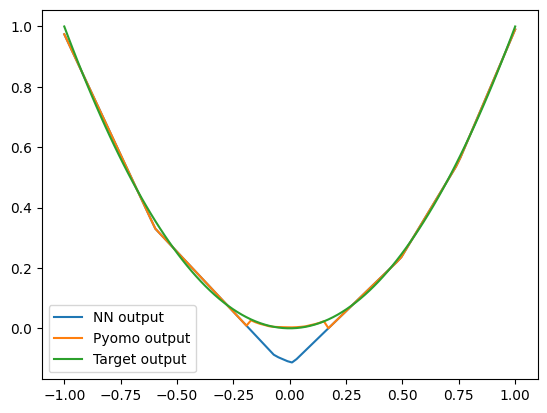

In [456]:
plt.plot(x, y, label = 'NN output')
plt.plot(x, primal_batch, label = 'Pyomo output')
plt.plot(x, y_target, label = 'Target output')
plt.legend()

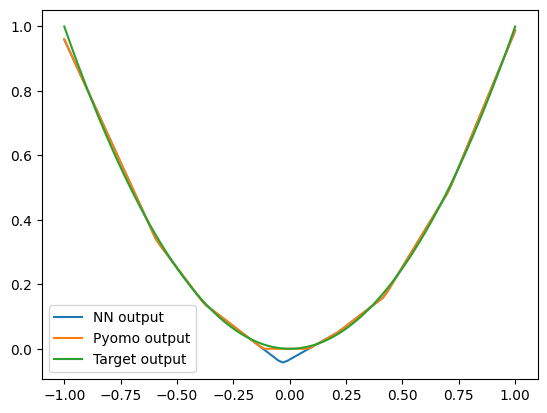

In [340]:
plt.plot(x, y, label = 'NN output')
plt.plot(x, primal_batch, label = 'Pyomo output')
plt.plot(x, y_target, label = 'Target output')
plt.legend()

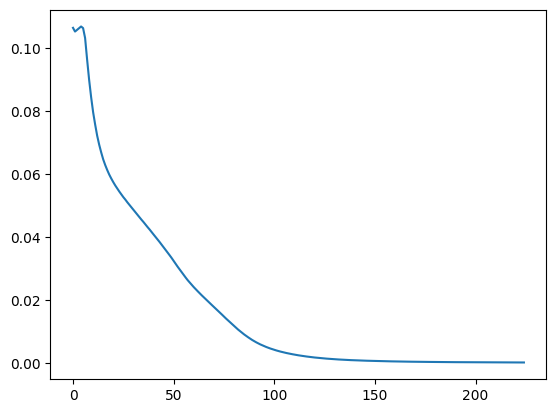

In [335]:
plt.plot(epoch_loss)

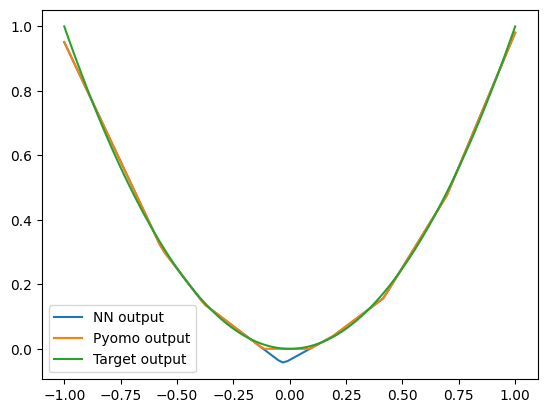

In [334]:
plt.plot(x, y, label = 'NN output')
plt.plot(x, primal_batch, label = 'Pyomo output')
plt.plot(x, y_target, label = 'Target output')
plt.legend()